In [1]:
import pandas as pd


In [2]:
file_path = "C:/Users/ACME IT/Downloads/resigndata.xlsx"

In [3]:
df = pd.read_excel(file_path)


In [4]:
print(df.head())


  EMP_ID       DESIGNATION            DPT_DIVISION RESIGN_DATE  \
0  31006  Senior Executive  Information Technology  2025-09-16   
1  31006  Senior Executive  Information Technology  2025-09-16   
2  31006  Senior Executive  Information Technology  2025-09-16   
3  31006  Senior Executive  Information Technology  2025-09-16   
4  31006  Senior Executive  Information Technology  2025-09-16   

                                            QUESTION  \
0             Performance & Reward Management System   
1  Reason Behind leaving The ACME Laboratories Lt...   
2                     Technology & Logistics Support   
3                     Technology & Logistics Support   
4                     Technology & Logistics Support   

                                              ANSWER ANSWER_GRADE COMMENTS  
0  The practice of KPI based perfomance managemen...            3      NaN  
1                                 Career advancement          NaN      NaN  
2  I received sufficient support wh

In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10114 entries, 0 to 10113
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   EMP_ID        10059 non-null  object        
 1   DESIGNATION   9996 non-null   object        
 2   DPT_DIVISION  9996 non-null   object        
 3   RESIGN_DATE   9996 non-null   datetime64[ns]
 4   QUESTION      10048 non-null  object        
 5   ANSWER        7678 non-null   object        
 6   ANSWER_GRADE  9243 non-null   object        
 7   COMMENTS      480 non-null    object        
dtypes: datetime64[ns](1), object(7)
memory usage: 632.3+ KB
None


In [7]:
print(df.isnull().sum())


EMP_ID            55
DESIGNATION      118
DPT_DIVISION     118
RESIGN_DATE      118
QUESTION          66
ANSWER          2436
ANSWER_GRADE     871
COMMENTS        9634
dtype: int64


In [8]:
df = df.drop_duplicates()


In [9]:
df.to_excel("cleaned_data.xlsx", index=False)


In [10]:
import numpy as np
import pandas as pd


df_filled = df.copy()   # এখানে df_cleaned এর বদলে df ব্যবহার করা হয়েছে

for col in df_filled.columns:
    if df_filled[col].dtype in [np.float64, np.int64]:  
        # Numeric হলে mean দিয়ে fill
        mean_val = df_filled[col].mean()
        df_filled[col] = df_filled[col].fillna(mean_val)
        
    elif col in ["DESIGNATION", "DPT_DIVISION", "ANSWER", "ANSWER_GRADE", "COMMEMTS"]:  
        # যদি column DESIGNATION বা DPT_DIVISION হয়, mode দিয়ে fill
        mode_val = df_filled[col].mode()[0]
        df_filled[col] = df_filled[col].fillna(mode_val)
        
    else:  
        # অন্য সব string column → "Unknown"
        df_filled[col] = df_filled[col].fillna("Unknown")

# Missing check
print(df_filled.isnull().sum())

# Cleaned data save
df_filled.to_excel("cleaned_resign_list.xlsx", index=False)
print("✅ Cleaned dataset saved as cleaned_resign_list.xlsx")
print("Rows, Columns:", df_filled.shape)


EMP_ID          0
DESIGNATION     0
DPT_DIVISION    0
RESIGN_DATE     0
QUESTION        0
ANSWER          0
ANSWER_GRADE    0
COMMENTS        0
dtype: int64
✅ Cleaned dataset saved as cleaned_resign_list.xlsx
Rows, Columns: (10064, 8)


In [11]:
# Resign date কে datetime বানাও
df_filled["RESIGN_DATE"] = pd.to_datetime(df_filled["RESIGN_DATE"], errors="coerce")

# প্রতি মাসে কত resign হয়েছে
monthly_resign = df_filled.groupby(df_filled["RESIGN_DATE"].dt.to_period("M"))["EMP_ID"].nunique()

print(monthly_resign)


RESIGN_DATE
2016-03     1
2017-01     1
2020-10     1
2022-12     1
2023-01     6
2023-02     7
2023-03     3
2023-04     5
2023-05     7
2023-06     6
2023-07    12
2023-08    11
2023-09     5
2023-10    17
2023-11    13
2023-12    10
2024-01     9
2024-02     7
2024-03     2
2024-04     8
2024-05     4
2024-06     9
2024-07     7
2024-08     5
2024-09     5
2024-10     4
2024-11     4
2024-12     6
2025-01     9
2025-02     4
2025-03     4
2025-04    10
2025-05     3
2025-06     8
2025-07     7
2025-08    11
2025-09     5
Freq: M, Name: EMP_ID, dtype: int64


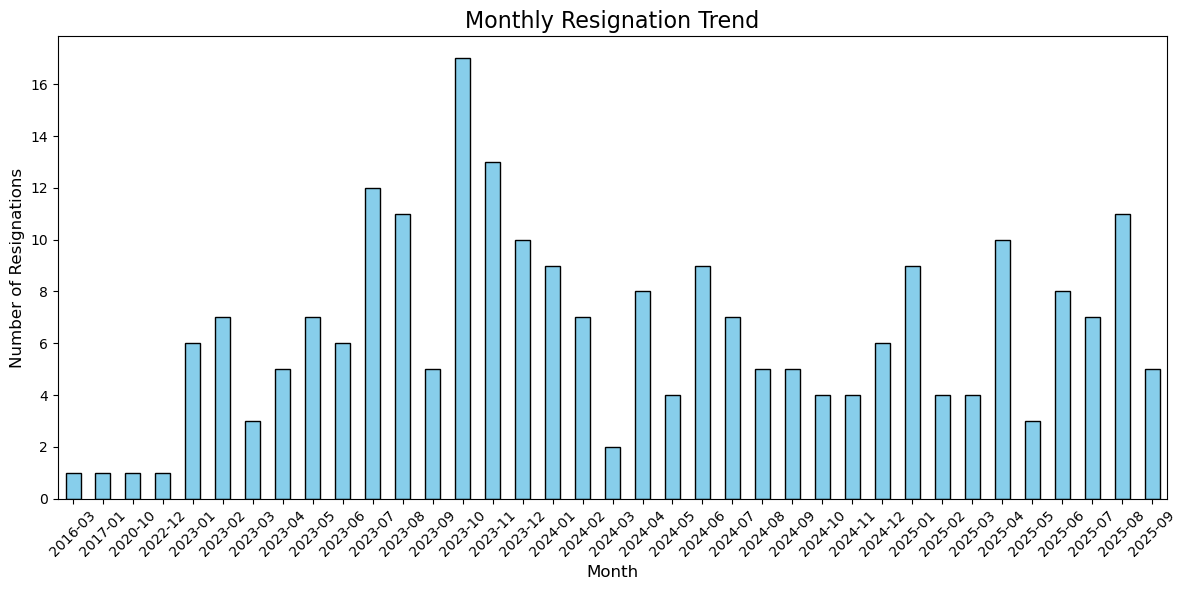

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
monthly_resign.plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Monthly Resignation Trend", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Resignations", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
dept_resign = df_filled.groupby("DPT_DIVISION")["EMP_ID"].nunique().sort_values(ascending=False)
print(dept_resign)


DPT_DIVISION
Quality Operation (SDU, BLS, HSU)                 133
Marketing                                          45
Research & Development                             32
Quality Operation (GNU,CPU,PNU,AHN)                17
Supply Chain Management                            10
International Business                              9
Engineering Operation                               7
API Plant Operation                                 5
Finance & Accounts                                  5
Legal, Regulatory & QMS                             5
HR & Administration                                 5
Information Technology                              4
Production Planning & Inventory Control (PPIC)      4
Factory Administration                              3
Production-CPU                                      2
Global Regulatory Affairs                           2
Production-GNU                                      2
Production-BLS Solid                                2
Distribution   

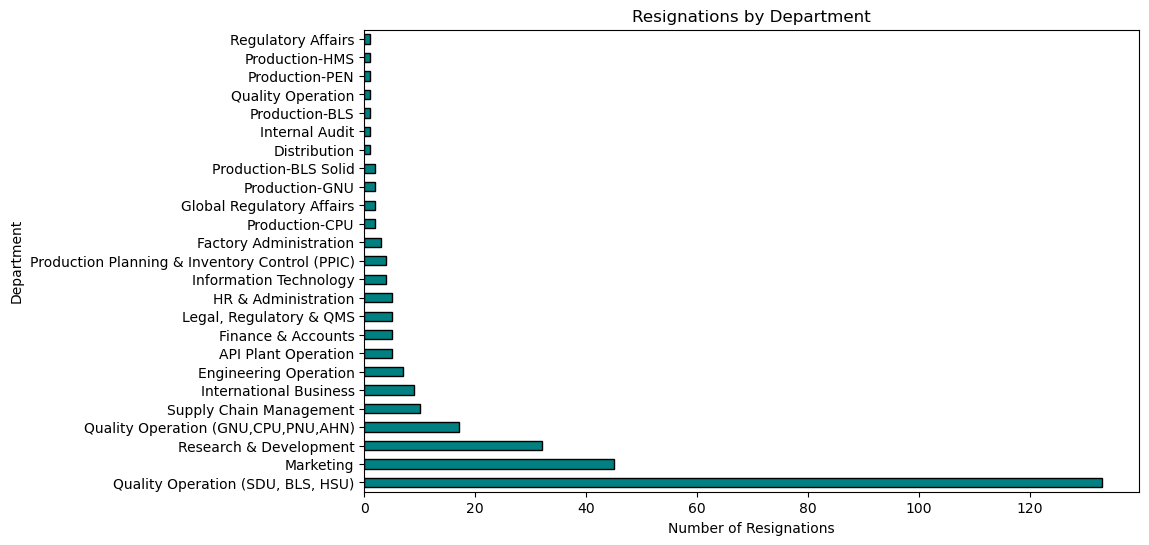

In [14]:
dept_resign.plot(kind="barh", figsize=(10,6), color="teal", edgecolor="black",
                 title="Resignations by Department")
plt.xlabel("Number of Resignations")
plt.ylabel("Department")
plt.show()


In [15]:
designation_resign = df_filled.groupby("DESIGNATION")["EMP_ID"].nunique().sort_values(ascending=False)
print(designation_resign)


DESIGNATION
Executive                           222
Senior Executive                     39
Assistant Manager                    21
Deputy Manager                        6
Senior Manager-II                     2
Manager                               2
Junior Officer-I                      2
Assistant Engineer-II                 1
Deputy General Manager                1
Assistant General Manager             1
Junior Officer-II                     1
Senior Assistant General Manager      1
Name: EMP_ID, dtype: int64


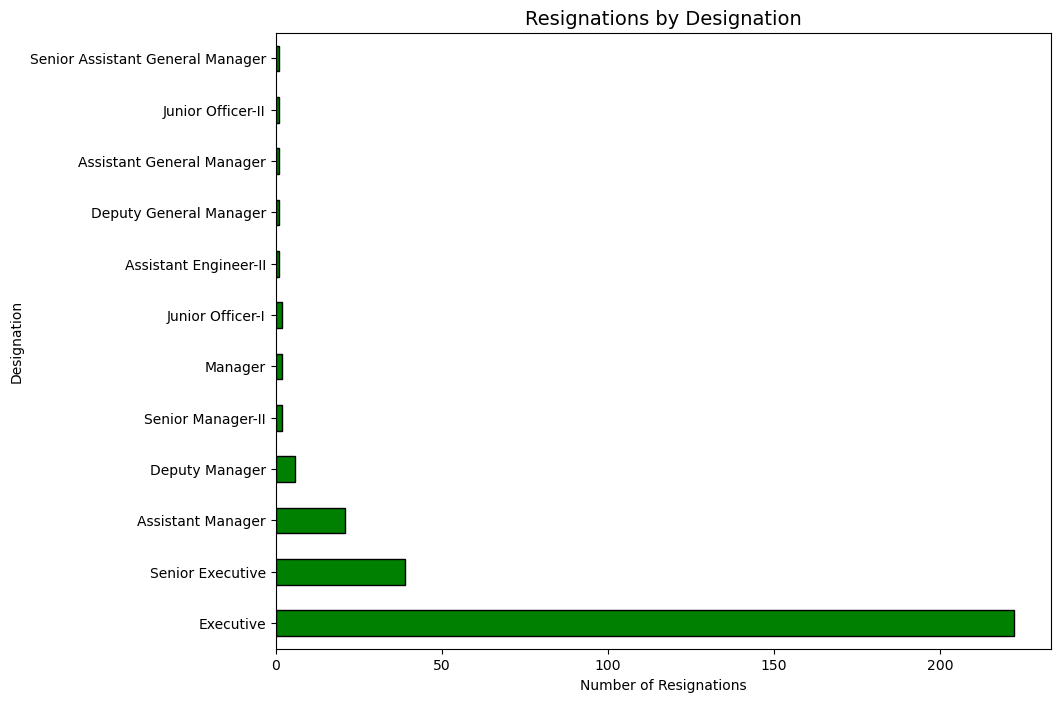

In [16]:
designation_resign.plot(kind="barh", figsize=(10,8), color="green", edgecolor="black")
plt.title("Resignations by Designation", fontsize=14)
plt.xlabel("Number of Resignations")
plt.ylabel("Designation")
plt.show()


In [17]:
reasons = df_filled[df_filled["QUESTION"].str.contains("reason", case=False, na=False)]
print(reasons["ANSWER"].value_counts().head(10))


ANSWER
ACME is focused on ensuring gender diversification at workplace    238
Family and /or peronal circumstances                                98
Career advancement                                                  95
Better benefits                                                     52
Career change                                                       51
Higher Pay                                                          36
Better work life balance                                            26
Commuting distance                                                  12
Conflict with managers                                               8
Conflict with other employees                                        2
Name: count, dtype: int64


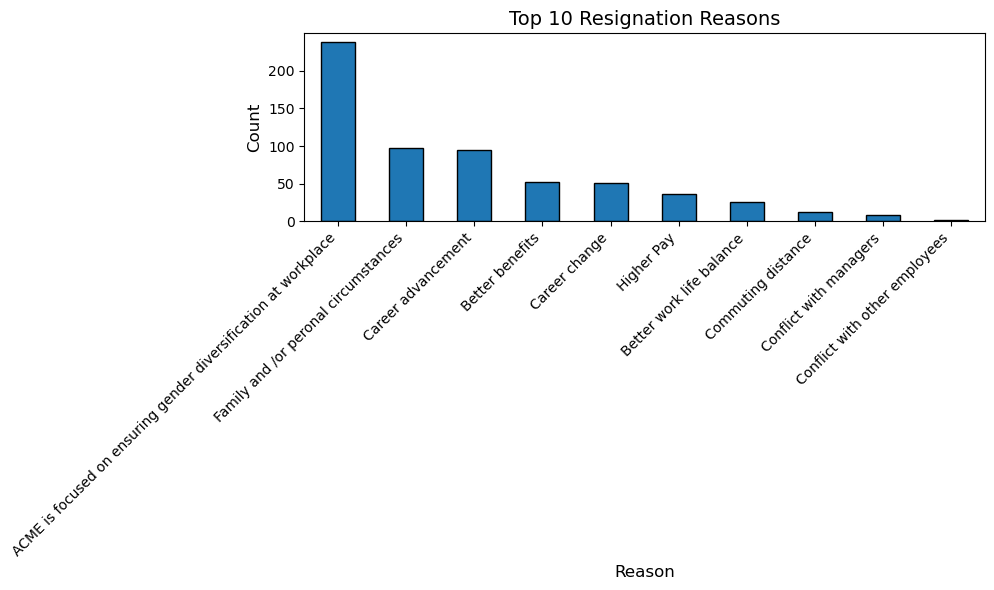

In [18]:
import matplotlib.pyplot as plt

# Filter করা reasons
reasons = df_filled[df_filled["QUESTION"].str.contains("reason", case=False, na=False)]

# Top 10 answers
top_reasons = reasons["ANSWER"].value_counts().head(10)

# Bar chart visualization
plt.figure(figsize=(10,6))
top_reasons.plot(kind="bar", edgecolor="black")

plt.title("Top 10 Resignation Reasons", fontsize=14)
plt.xlabel("Reason", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


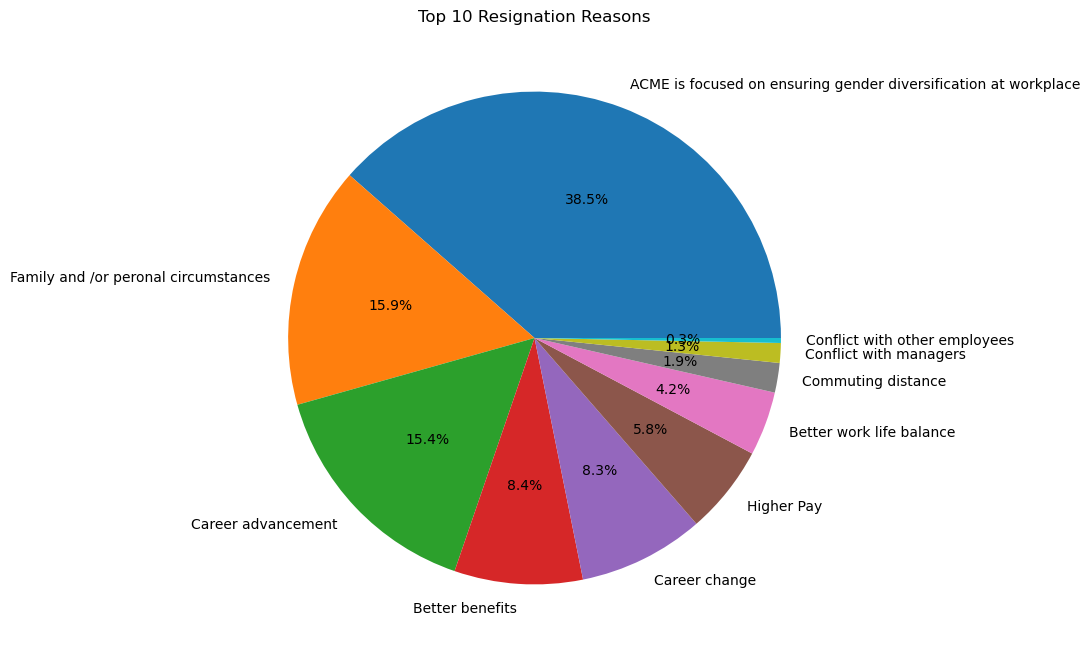

In [19]:
top_reasons.plot(kind="pie", autopct='%1.1f%%', figsize=(8,8))
plt.title("Top 10 Resignation Reasons")
plt.ylabel("")  # y-label hide
plt.show()


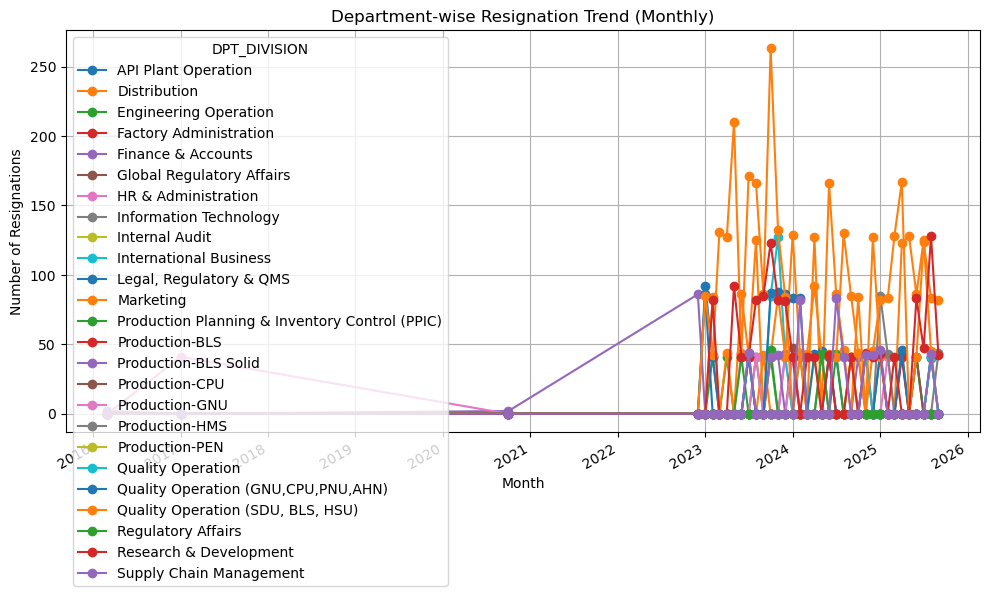

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load data ---
file_path = r"C:\Users\ACME IT\Documents\resigndata.xlsx" # <-- এখানে সঠিক path বসাও
df = pd.read_excel(file_path, sheet_name="EMP_EXIT_FORM")

# তারিখ ফরম্যাটে কনভার্ট
df['RESIGN_DATE'] = pd.to_datetime(df['RESIGN_DATE'], errors='coerce')
df = df.dropna(subset=['RESIGN_DATE']).copy()

# মাস অনুযায়ী group করা
df['RESIGN_YYYY_MM'] = df['RESIGN_DATE'].dt.to_period('M').dt.to_timestamp()

# প্রতি মাসে প্রতি department কতজন resign করেছে
pivot = (
    df.groupby(['RESIGN_YYYY_MM', 'DPT_DIVISION'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

# --- Plot ---
pivot.plot(marker='o', figsize=(10,6))
plt.title("Department-wise Resignation Trend (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Resignations")
plt.grid(True)
plt.tight_layout()
plt.show()



In [24]:
pip install vaderSentiment


Note: you may need to restart the kernel to use updated packages.


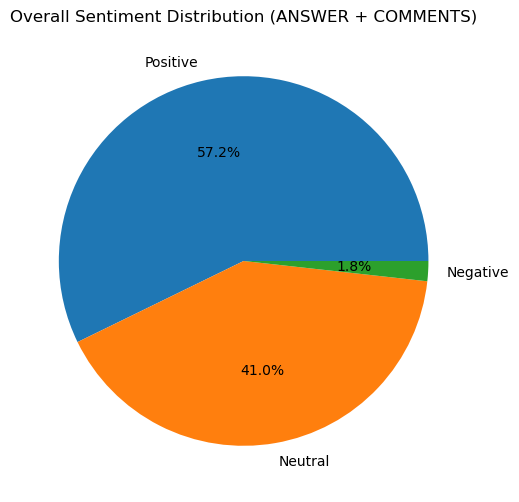


Department-wise sentiment counts:
SENTIMENT                  Negative  Neutral  Positive
DPT_DIVISION                                          
API Plant Operation               3       91       118
Distribution                      0       16        26
Engineering Operation             2      105       186
Factory Administration            2       51        73
Finance & Accounts                3      109       144
Global Regulatory Affairs         0       33        50
HR & Administration               3       85       120
Information Technology            3       73        96
Internal Audit                    2       16        23
International Business            7      155       217


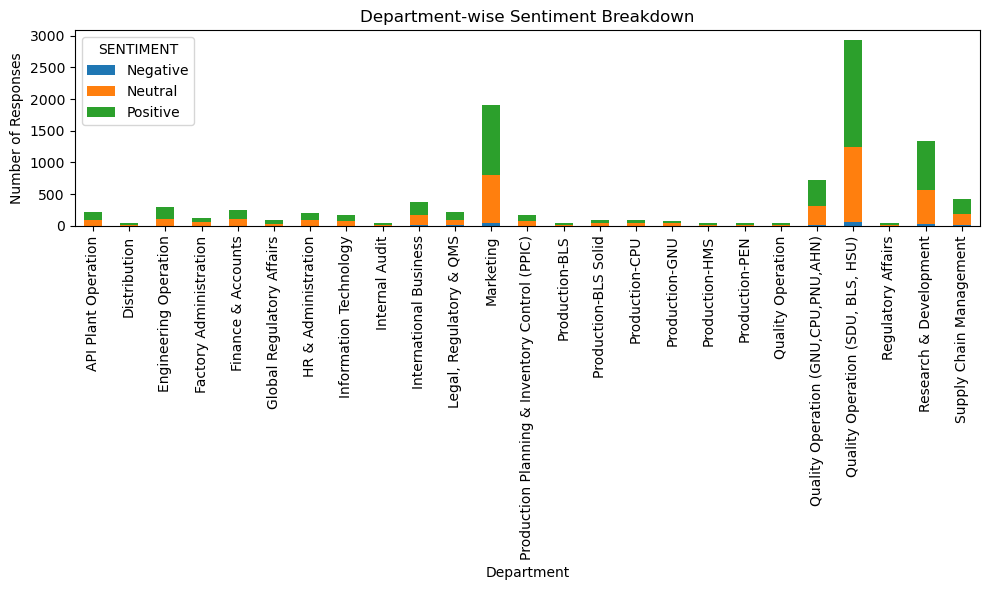

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# --- Load data ---
file_path = r"C:\Users\ACME IT\Documents\resigndata.xlsx"
df = pd.read_excel(file_path, sheet_name="EMP_EXIT_FORM")

# ANSWER + COMMENTS একত্র করা (NaN কে "" করে ফেলছি)
df['TEXT'] = df[['ANSWER', 'COMMENTS']].fillna('').astype(str).agg(' '.join, axis=1)

# --- Sentiment Analyzer ---
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']  # compound score -1 থেকে +1
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df['SENTIMENT'] = df['TEXT'].apply(get_sentiment)

# --- Overall sentiment distribution ---
df['SENTIMENT'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', figsize=(6,6), ylabel=''
)
plt.title("Overall Sentiment Distribution (ANSWER + COMMENTS)")
plt.show()

# --- Department-wise breakdown ---
dept_sentiment = df.groupby(['DPT_DIVISION', 'SENTIMENT']).size().unstack(fill_value=0)

print("\nDepartment-wise sentiment counts:")
print(dept_sentiment.head(10))

# Plot stacked bar for department-wise sentiment
dept_sentiment.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Department-wise Sentiment Breakdown")
plt.xlabel("Department")
plt.ylabel("Number of Responses")
plt.tight_layout()
plt.show()



=== Grouped questions ===

Work Support:
  - Technology & Logistics Support
  - Training & Career Development

Management & Relationship:
  - Performance & Reward Management System
  - Relationship With Supervisor(s)

Job Experience:
  - Job Satisfaction
  - How would you describe the culture here ?
  - Company Culture & Work Environment

Compensation:
  - Compensation & benefits

Exit Motivation:
  - Reason Behind leaving The ACME Laboratories Ltd ?
  - Are there any other comments you would like to make (suggestions, concerns, opportunities etc)?
  - Is there anything we could have done to change your decision to leave the company?

Unmapped questions:
  - nan

=== Category Grade Summary ===
                           responses  mean_grade  median_grade
Category                                                      
Compensation                     711        4.27           5.0
Exit Motivation                    0         NaN           NaN
Job Experience                  2370        

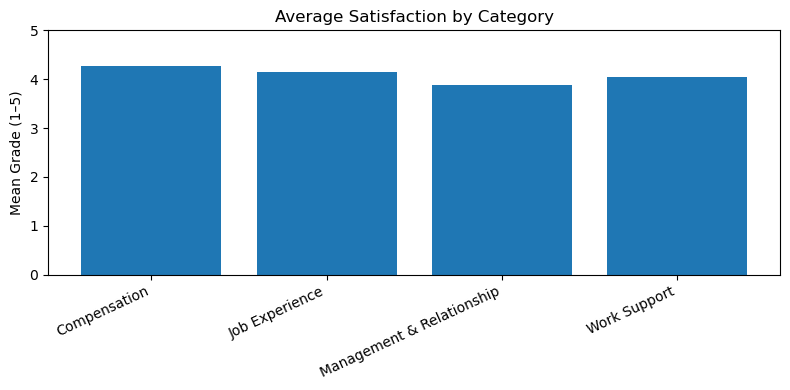

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# ---------- USER CONFIG ----------
FILEPATH = "C:/Users/ACME IT/Downloads/resigndata.xlsx"   # your file path
SHEETNAME = "EMP_EXIT_FORM"
QUESTION_COL = "QUESTION"
GRADE_COL = "ANSWER_GRADE"
# ---------------------------------

# 1) Load data
if not os.path.exists(FILEPATH):
    raise FileNotFoundError(f"File not found: {FILEPATH}")

df = pd.read_excel(FILEPATH, sheet_name=SHEETNAME)

# Clean and normalize
df[QUESTION_COL] = df[QUESTION_COL].astype(str).str.strip()
df[GRADE_COL] = pd.to_numeric(df.get(GRADE_COL), errors="coerce")

# 2) Define groups
groups = {
    "Work Support": [
        "Technology & Logistics Support",
        "Training & Career Development"
    ],
    "Management & Relationship": [
        "Relationship With Supervisor(s)",
        "Performance & Reward Management System"
    ],
    "Job Experience": [
        "Job Satisfaction",
        "Company Culture & Work Environment",
        "How would you describe the culture here ?"
    ],
    "Compensation": [
        "Compensation & benefits"
    ],
    "Exit Motivation": [
        "Reason Behind leaving The ACME Laboratories Ltd ? ",
        "Is there anything we could have done to change your decision to leave the company?",
        "Are there any other comments you would like to make (suggestions, concerns, opportunities etc)?"
    ]
}

# Build reverse lookup
reverse_map = {q.strip().lower(): cat for cat, qs in groups.items() for q in qs}

# Assign category
df["Category"] = df[QUESTION_COL].str.lower().map(reverse_map).fillna("Unmapped")

# 3) Grouped questions (which ones found in each category)
grouped_questions = {
    cat: df.loc[df["Category"] == cat, QUESTION_COL].unique().tolist()
    for cat in groups.keys()
}
unmapped = df.loc[df["Category"] == "Unmapped", QUESTION_COL].unique().tolist()

print("\n=== Grouped questions ===")
for cat, qlist in grouped_questions.items():
    print(f"\n{cat}:")
    for q in qlist:
        print("  -", q)
print("\nUnmapped questions:")
for q in unmapped:
    print("  -", q)

# 4) Average grade per category (1–5)
summary = (
    df.groupby("Category")[GRADE_COL]
    .agg(["count", "mean", "median"])
    .rename(columns={"count": "responses", "mean": "mean_grade", "median": "median_grade"})
    .round(2)
)
print("\n=== Category Grade Summary ===")
print(summary)

# 5) Optional: Bar chart
plot_df = summary.dropna(subset=["mean_grade"])
if not plot_df.empty:
    plt.figure(figsize=(8,4))
    plt.bar(plot_df.index, plot_df["mean_grade"])
    plt.ylim(0,5)
    plt.ylabel("Mean Grade (1–5)")
    plt.title("Average Satisfaction by Category")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric grades available for plotting.")


In [2]:
import pandas as pd
from collections import Counter
import re

# Load your file
file_path = "C:/Users/ACME IT/Downloads/resigndata.xlsx"
df = pd.read_excel(file_path, sheet_name="EMP_EXIT_FORM")

# Select only the exit-related questions
exit_questions = [
    "Reason Behind leaving The ACME Laboratories Ltd ? ",
    "Is there anything we could have done to change your decision to leave the company?",
    "Are there any other comments you would like to make (suggestions, concerns, opportunities etc)?"
]

exit_df = df[df["QUESTION"].isin(exit_questions)].copy()

# Combine all answers
text_data = " ".join(str(a) for a in exit_df["ANSWER"].dropna())

# Clean and lowercase
clean_text = re.sub(r"[^A-Za-z\s]", "", text_data).lower().split()

# Simple stopwords
stopwords = {
    "the","a","an","of","to","and","is","in","on","for","with",
    "my","at","that","it","this","as","was","are","be","i","me","we","you","our","your"
}

# Filter useful words
filtered = [w for w in clean_text if w not in stopwords and len(w) > 2]

# Count most common keywords
freq = Counter(filtered).most_common(20)

# Display result
print("Top 20 keywords mentioned in resignation reasons:\n")
for word, count in freq:
    print(f"{word}: {count}")


Top 20 keywords mentioned in resignation reasons:

career: 146
family: 99
peronal: 99
circumstances: 99
advancement: 95
better: 78
benefits: 52
change: 51
higher: 36
pay: 36
work: 26
life: 26
balance: 26
commuting: 12
distance: 12
conflict: 10
managers: 8
other: 2
employees: 2
business: 1


Top 10 Reasons for Job Resignation (based on word frequency):

career: 146
family: 99
peronal: 99
circumstances: 99
advancement: 95
better: 78
benefits: 52
change: 51
higher: 36
pay: 36


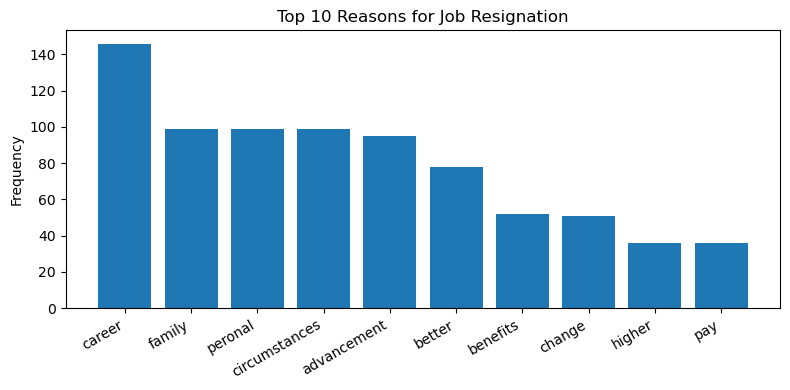

In [3]:
import pandas as pd
from collections import Counter
import re

# === STEP 1: Load file ===
file_path = "C:/Users/ACME IT/Downloads/resigndata.xlsx"
df = pd.read_excel(file_path, sheet_name="EMP_EXIT_FORM")

# === STEP 2: Filter Exit Motivation questions ===
exit_questions = [
    "Reason Behind leaving The ACME Laboratories Ltd ? ",
    "Is there anything we could have done to change your decision to leave the company?",
    "Are there any other comments you would like to make (suggestions, concerns, opportunities etc)?"
]
exit_df = df[df["QUESTION"].isin(exit_questions)].copy()

# === STEP 3: Combine all answers ===
text_data = " ".join(str(a) for a in exit_df["ANSWER"].dropna())

# === STEP 4: Clean text (remove punctuation, lowercase) ===
clean_text = re.sub(r"[^A-Za-z\s]", "", text_data).lower().split()

# === STEP 5: Define stopwords ===
stopwords = {
    "the","a","an","of","to","and","is","in","on","for","with",
    "my","at","that","it","this","as","was","are","be","i","me","we",
    "you","our","your","from","by","have","had","been","were","they",
    "their","them","or","but"
}

# === STEP 6: Filter out stopwords and small words ===
filtered = [w for w in clean_text if w not in stopwords and len(w) > 2]

# === STEP 7: Count top 10 keywords ===
top_reasons = Counter(filtered).most_common(10)

# === STEP 8: Display the result ===
print("Top 10 Reasons for Job Resignation (based on word frequency):\n")
for word, count in top_reasons:
    print(f"{word}: {count}")

# === (Optional) STEP 9: Bar chart visualization ===
import matplotlib.pyplot as plt

if top_reasons:
    words, counts = zip(*top_reasons)
    plt.figure(figsize=(8,4))
    plt.bar(words, counts)
    plt.title("Top 10 Reasons for Job Resignation")
    plt.ylabel("Frequency")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


Top 10 Exact Reasons for Job Resignation:

99 times: Family and /or peronal circumstances
95 times: Career advancement
52 times: Better benefits
51 times: Career change
36 times: Higher Pay
26 times: Better work life balance
12 times: Commuting distance
8 times: Conflict with managers
2 times: Conflict with other employees
1 times: Business direction


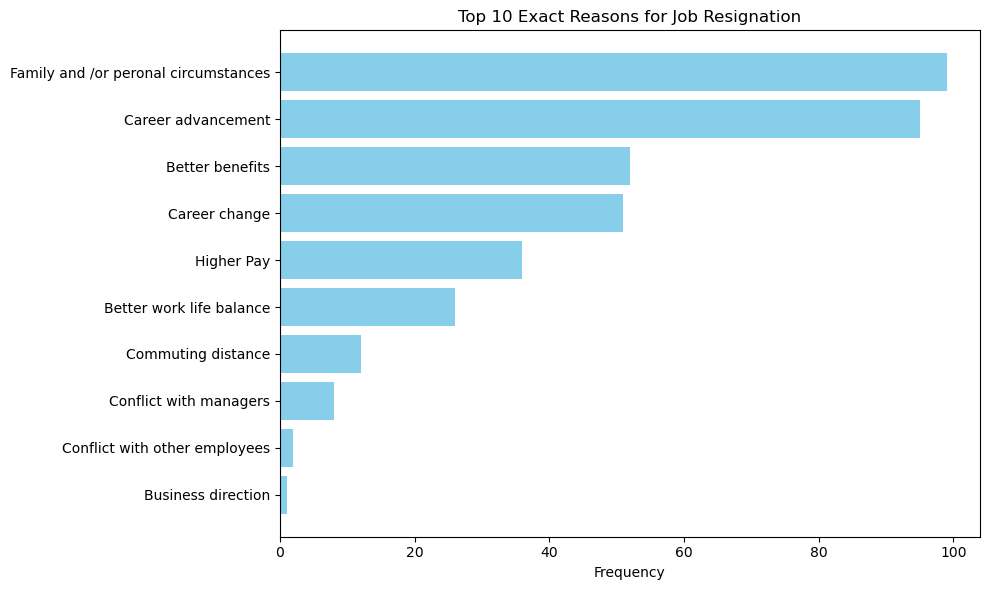

In [5]:
import pandas as pd
from collections import Counter

# === STEP 1: Load file ===
file_path = "C:/Users/ACME IT/Downloads/resigndata.xlsx"
df = pd.read_excel(file_path, sheet_name="EMP_EXIT_FORM")

# === STEP 2: Filter Exit Motivation questions ===
exit_questions = [
    "Reason Behind leaving The ACME Laboratories Ltd ? ",
    "Is there anything we could have done to change your decision to leave the company?",
    "Are there any other comments you would like to make (suggestions, concerns, opportunities etc)?"
]
exit_df = df[df["QUESTION"].isin(exit_questions)].copy()

# === STEP 3: Get all answers as list and remove NaNs ===
answers = exit_df["ANSWER"].dropna().tolist()

# === STEP 4: Count exact same reasons ===
reason_counts = Counter(answers)

# === STEP 5: Get top 10 most common reasons ===
top_reasons = reason_counts.most_common(10)

# === STEP 6: Display results ===
print("Top 10 Exact Reasons for Job Resignation:\n")
for reason, count in top_reasons:
    print(f"{count} times: {reason}")

# === Optional: Bar chart visualization ===
import matplotlib.pyplot as plt

if top_reasons:
    reasons, counts = zip(*top_reasons)
    plt.figure(figsize=(10,6))
    plt.barh(reasons, counts, color='skyblue')
    plt.xlabel("Frequency")
    plt.title("Top 10 Exact Reasons for Job Resignation")
    plt.gca().invert_yaxis()  # highest on top
    plt.tight_layout()
    plt.show()
